C:\Users\nguye\AppData\Local\Temp\ipykernel_17464\3560894124.py:10: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")


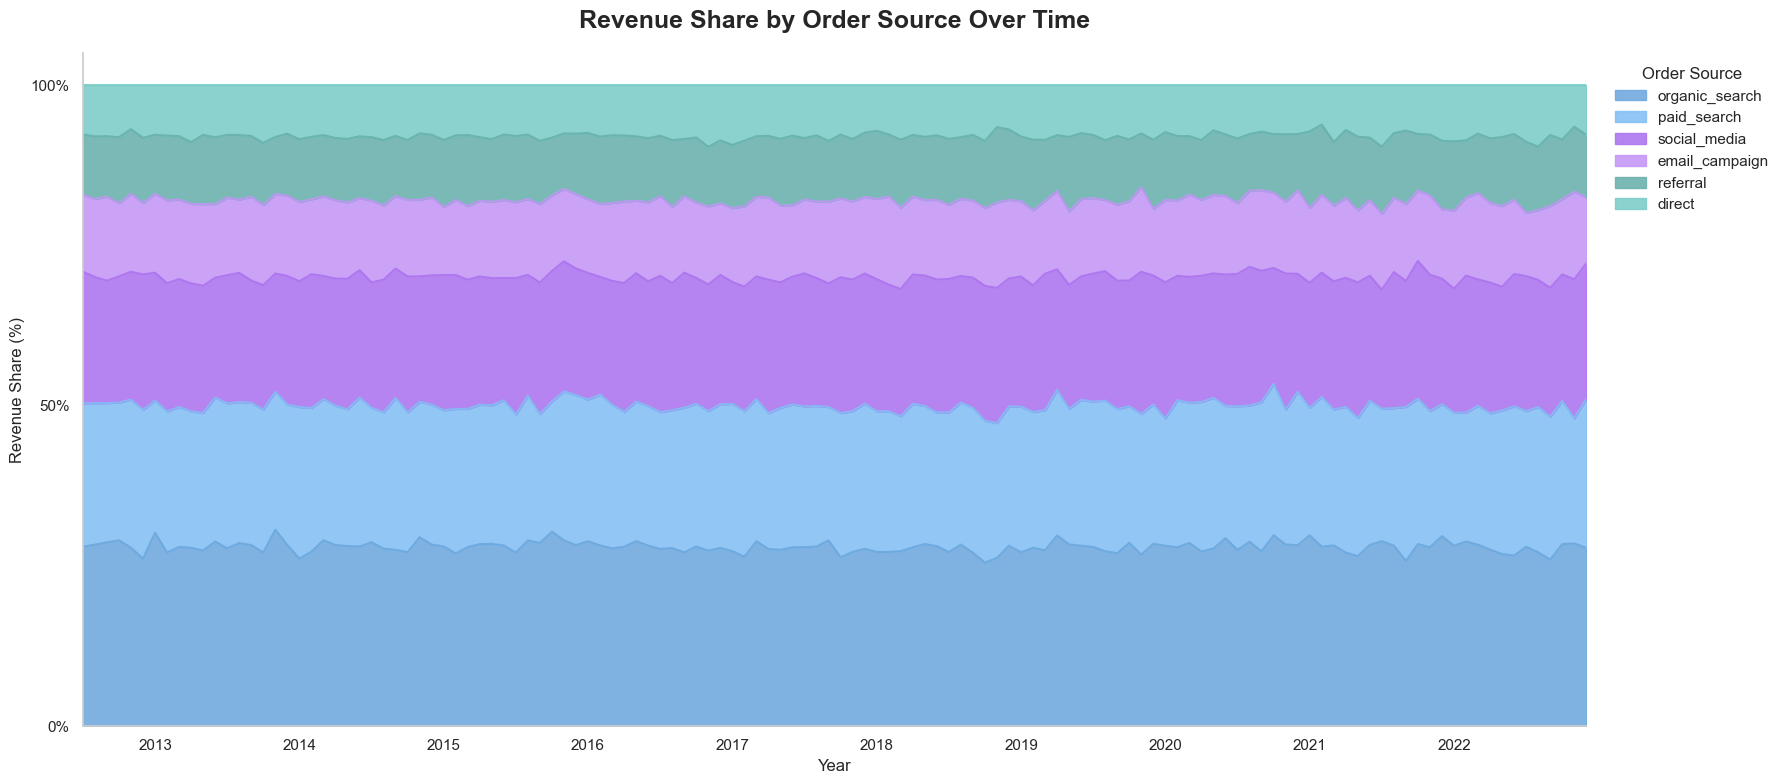

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set(style="whitegrid")

# Load data
orders = pd.read_csv("../data/orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv("../data/order_items.csv")

# Compute revenue
order_items["revenue"] = (
    order_items["quantity"] * order_items["unit_price"]
    - order_items["discount_amount"]
)

# Merge order source
df = order_items.merge(
    orders[["order_id", "order_date", "order_source"]],
    on="order_id",
    how="left"
)

# Aggregate by month and order source
df["month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

monthly_revenue = (
    df.groupby(["month", "order_source"])["revenue"]
    .sum()
    .reset_index()
)

# Pivot table
pivot = monthly_revenue.pivot(
    index="month",
    columns="order_source",
    values="revenue"
).fillna(0)

# Sort sources by total revenue
pivot = pivot[pivot.sum().sort_values(ascending=False).index]

# Convert revenue to revenue share
pivot_share = pivot.div(pivot.sum(axis=1), axis=0)

# Colors
colors = [
    "#6DA8DD",
    "#82BFF4",
    "#AC73EE",
    "#C396F7",
    "#68B0AC",
    "#7BCCC8",
]

assert len(colors) == pivot_share.shape[1], "Số màu không khớp với số lượng order_source"

# Export data to CSV
pivot_share.reset_index().to_csv(
    "../data/revenue_share_by_order_source.csv",
    index=False
)

# Plot
fig, ax = plt.subplots(figsize=(18, 8))

pivot_share.plot.area(
    ax=ax,
    alpha=0.88,
    color=colors
)

ax.set_title(
    "Revenue Share by Order Source Over Time",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Year")
ax.set_ylabel("Revenue Share (%)")

# Y-axis: 0%, 50%, 100%
ax.set_yticks([0, 0.5, 1])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# X-axis: chỉ hiển thị năm
year_ticks = pivot_share.index[pivot_share.index.month == 1]

ax.set_xticks(year_ticks)
ax.set_xticklabels(
    [d.strftime("%Y") for d in year_ticks],
    rotation=0
)

ax.legend(
    title="Order Source",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False
)

ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

pivot_share.to_csv("db4-data/revenue_share_by_order_source.csv")

c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\nguye\AppData\Local\Temp\ipykernel_19184\942819088.py:21: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([traffic_ts, orders_ts], axis=1)


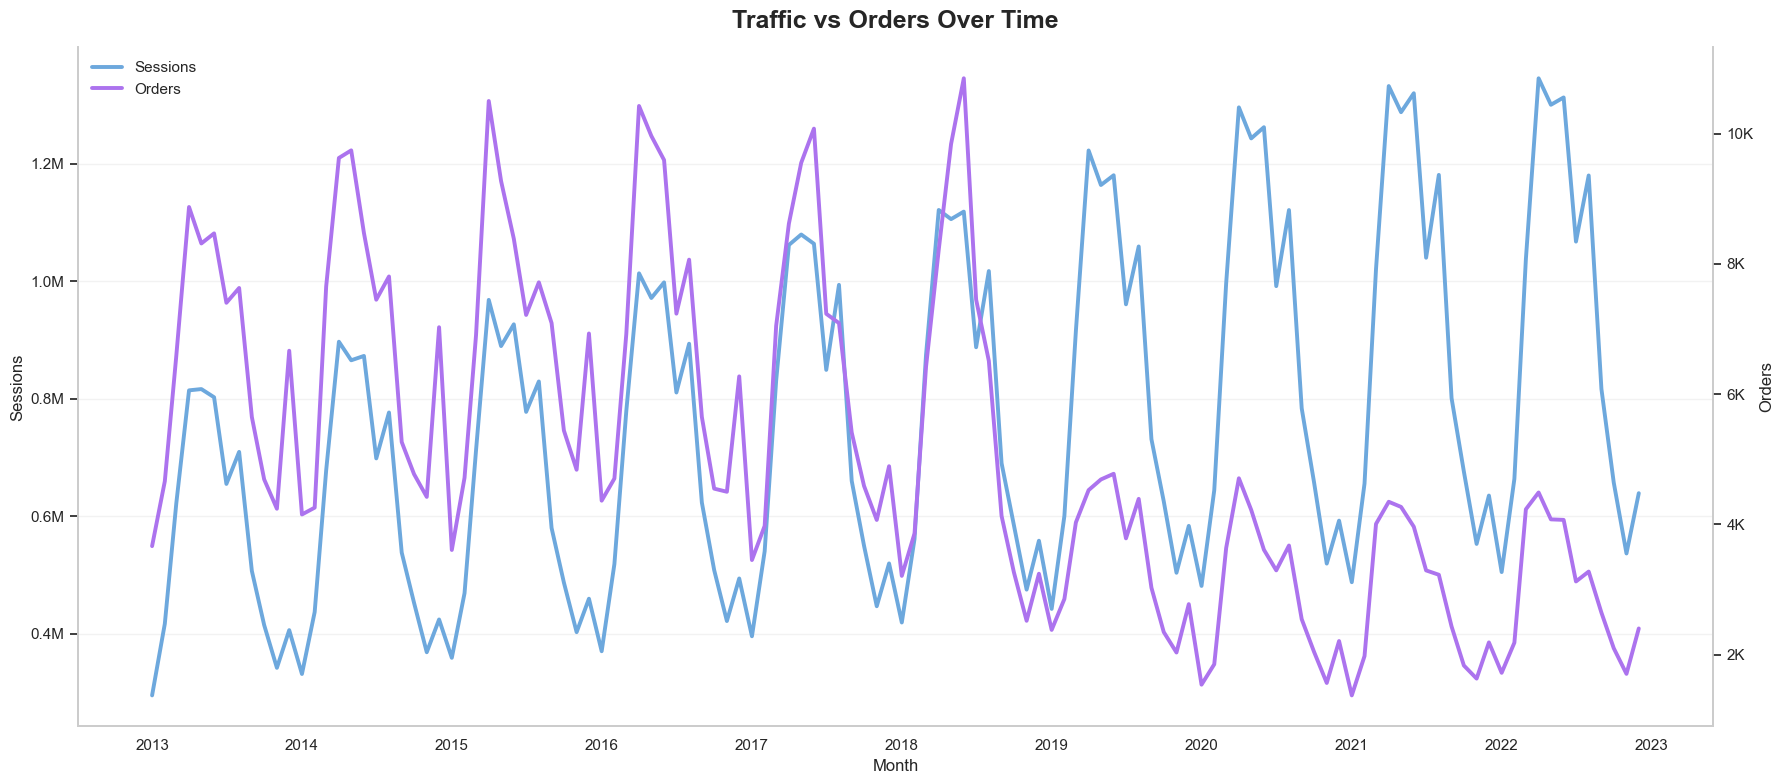

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set(style="whitegrid")

# Load data
traffic = pd.read_csv("../data/web_traffic.csv", parse_dates=["date"])
orders = pd.read_csv("../data/orders.csv", parse_dates=["order_date"])

# Monthly traffic
traffic["month"] = traffic["date"].dt.to_period("M").dt.to_timestamp()
traffic_ts = traffic.groupby("month")["sessions"].sum()

# Monthly orders
orders["month"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()
orders_ts = orders.groupby("month")["order_id"].nunique()

# Combine
df = pd.concat([traffic_ts, orders_ts], axis=1)
df.columns = ["sessions", "orders"]
df = df.dropna()

# Plot dual-axis
fig, ax1 = plt.subplots(figsize=(18, 8))

# Left axis: Sessions
ax1.plot(
    df.index,
    df["sessions"],
    color="#6DA8DD",
    linewidth=2.8,
    label="Sessions"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Sessions")
ax1.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

# Right axis: Orders
ax2 = ax1.twinx()

ax2.plot(
    df.index,
    df["orders"],
    color="#AC73EE",
    linewidth=2.8,
    label="Orders"
)

ax2.set_ylabel("Orders")
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1_000:.0f}K")
)

# Title
ax1.set_title(
    "Traffic vs Orders Over Time",
    fontsize=18,
    fontweight="bold",
    pad=14
)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    frameon=False
)

# Style
ax1.grid(axis="y", alpha=0.25)
ax1.grid(axis="x", visible=False)
ax2.grid(False)

sns.despine(right=False)

plt.tight_layout()
plt.show()

df.to_csv("db4-data/traffic_orders_monthly.csv", index=True)

C:\Users\nguye\AppData\Local\Temp\ipykernel_17464\1730749773.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


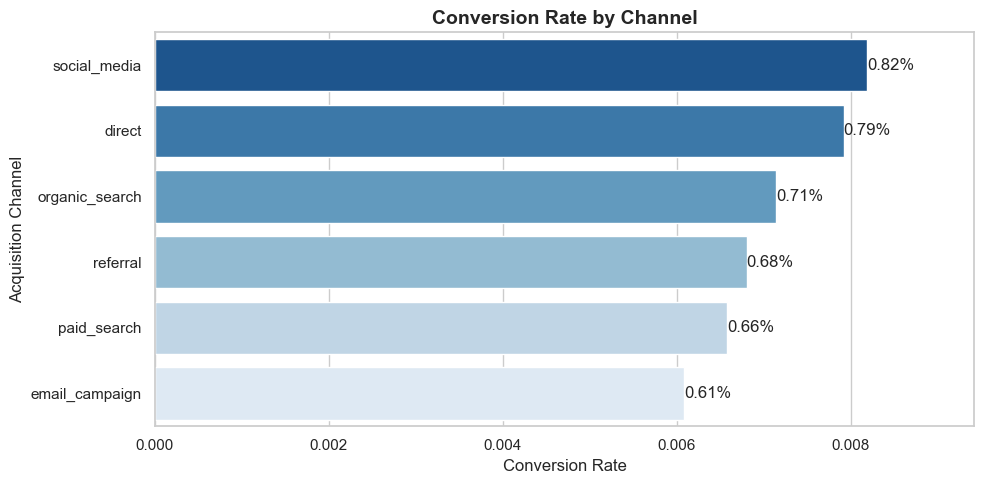

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# =========================
# Load data
# =========================
orders = pd.read_csv("../data/orders.csv")
customers = pd.read_csv("../data/customers.csv")
traffic = pd.read_csv("../data/web_traffic.csv")

# =========================
# Merge customer info
# =========================
df = orders.merge(
    customers[["customer_id", "acquisition_channel"]],
    on="customer_id",
    how="left"
)

# =========================
# Orders by channel
# =========================
orders_seg = (
    df.groupby("acquisition_channel")
    .size()
    .rename("orders")
    .reset_index()
)

# =========================
# Traffic by source
# =========================
traffic_seg = (
    traffic.groupby("traffic_source")["sessions"]
    .sum()
    .rename("sessions")
)

# =========================
# Merge (map channel)
# =========================
conversion = orders_seg.merge(
    traffic_seg,
    left_on="acquisition_channel",
    right_index=True,
    how="left"
)

# =========================
# Conversion rate
# =========================
conversion["conversion_rate"] = conversion["orders"] / conversion["sessions"]

conversion = conversion.dropna()

# =========================
# Sort cho dễ nhìn
# =========================
conversion = conversion.sort_values("conversion_rate", ascending=False)

# =========================
# Plot (bar chart thay vì heatmap)
# =========================
plt.figure(figsize=(10,5))

sns.barplot(
    data=conversion,
    x="conversion_rate",
    y="acquisition_channel",
    palette="Blues_r"
)

# annotate %
for i, v in enumerate(conversion["conversion_rate"]):
    plt.text(v, i, f"{v:.2%}", va='center')

plt.title("Conversion Rate by Channel", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Rate")
plt.ylabel("Acquisition Channel")

plt.xlim(0, conversion["conversion_rate"].max() * 1.15)

plt.tight_layout()
plt.show()